<a href="https://colab.research.google.com/github/FelipeMello987/CP_02_SERS_01-10-26/blob/main/Aula_APIs_Energia_Renovavel_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [1]:
import json
import urllib.parse
import urllib.request
import csv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [2]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=30) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [3]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


In [4]:
registros_aneel = []
for sigla in SIGLAS:
    parametros = {
        "resource_id": ID_RECURSO,
        "filters": json.dumps({"SigTipoGeracao": sigla}),
        "limit": 1200,
    }
    resposta = consultar_api(URL_ANEEL, parametros)
    if not resposta.get("success"):
        raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
    linhas = resposta["result"]["records"]
    print(f"{sigla}: {len(linhas)} linhas recebidas")
    registros_aneel.extend(linhas)
print("Total de linhas recebidas:", len(registros_aneel))

RuntimeError: Não foi possível consultar a API: <urlopen error timed out>

### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [ ]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}
linhas_classificacao = []
for registro in registros_aneel:
    potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
    latitude = numero(registro.get("NumCoordNEmpreendimento"))
    longitude = numero(registro.get("NumCoordEEmpreendimento"))
    fonte = fontes.get(registro.get("SigTipoGeracao"))
    if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
        linhas_classificacao.append([potencia, latitude, longitude, fonte])
if len(linhas_classificacao) < 90:
    raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
print("Linhas válidas:", len(linhas_classificacao))
print("Primeiro exemplo:", linhas_classificacao[0])

In [ ]:
with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
    escritor.writerows(linhas_classificacao)
print("Salvo: aneel_classificacao_orange.csv")

### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

In [20]:
df_aneel = pd.read_csv('/content/aneel_classificacao_orange.csv')
df_aneel.head()

,potencia_kw,latitude,longitude,fonte
0,20.48,-10.442778,-64.151944,Solar
1,5000.00,-6.003889,-40.274722,Solar
2,12.26,-23.557778,-46.734000,Solar
3,3.00,-23.558889,-46.735000,Solar
4,1.70,-23.493819,-46.845000,Solar


In [21]:
df_aneel.columns

Index(['potencia_kw', 'latitude', 'longitude', 'fonte'], dtype='object')

In [22]:
print(f"quantidade de linhas: {df_aneel.shape[0]}")
print(f"quantidade de colunas: {df_aneel.shape[1]}")

quantidade de linhas: 3876
quantidade de colunas: 4


In [23]:
print(df_aneel['fonte'].value_counts())
df_aneel.describe()

fonte
Hidráulica    1476
Solar         1200
Eólica        1200
Name: count, dtype: int64


,potencia_kw,latitude,longitude
count,3.876000e+03,3876.000000,3876.000000
mean,4.201468e+04,-12.693951,-46.158299
std,3.016366e+05,9.500523,8.357453
min,1.600000e-01,-33.722806,-69.941389
25%,4.400000e+02,-21.142110,-52.561817
50%,1.268000e+04,-10.469532,-47.393697
75%,3.000000e+04,-4.127788,-41.280013
max,1.123310e+07,3.831392,0.000000


In [24]:
nulo = df_aneel.isnull().sum()
nulo

,0
potencia_kw,0
latitude,0
longitude,0
fonte,0


In [25]:
df_aneel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3876 entries, 0 to 3875
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   potencia_kw  3876 non-null   float64
 1   latitude     3876 non-null   float64
 2   longitude    3876 non-null   float64
 3   fonte        3876 non-null   object 
dtypes: float64(3), object(1)
memory usage: 121.3+ KB


In [26]:
from sklearn.preprocessing import StandardScaler

x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

escala = StandardScaler()
x_treino_esc = escala.fit_transform(x_treino)
x_teste_esc = escala.transform(x_teste)

In [27]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

modelo_knn = KNeighborsClassifier()
modelo_logreg = LogisticRegression()
modelo_rf = RandomForestClassifier()

In [28]:
import warnings
warnings.filterwarnings('ignore')

In [29]:
modelo_knn.fit(x_treino, y_treino)

KNeighborsClassifier()

In [30]:
modelo_logreg.fit(x_treino, y_treino)

LogisticRegression()

In [31]:
modelo_rf.fit(x_treino, y_treino)

RandomForestClassifier()

In [32]:
modelo_knn = KNeighborsClassifier()
modelo_logreg = LogisticRegression(max_iter=1000)
modelo_rf = RandomForestClassifier(random_state=42)

modelo_knn.fit(x_treino_esc, y_treino)
modelo_logreg.fit(x_treino_esc, y_treino)
modelo_rf.fit(x_treino_esc, y_treino)

RandomForestClassifier(random_state=42)

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

modelos = {'KNN': modelo_knn, 'Regressão Logística': modelo_logreg, 'Random Forest': modelo_rf}

linhas = []
for nome, modelo in modelos.items():
    y_pred = modelo.predict(x_teste_esc)
    linhas.append({
        'Modelo': nome,
        'Accuracy': accuracy_score(y_teste, y_pred),
        'Precision (macro)': precision_score(y_teste, y_pred, average='macro', zero_division=0),
        'Recall (macro)': recall_score(y_teste, y_pred, average='macro', zero_division=0),
        'F1 (macro)': f1_score(y_teste, y_pred, average='macro', zero_division=0)
    })

tabela = pd.DataFrame(linhas).round(3)
tabela

,Modelo,Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,KNN,0.965,0.966,0.964,0.965
1,Regressão Logística,0.825,0.828,0.821,0.820
2,Random Forest,0.976,0.977,0.974,0.975


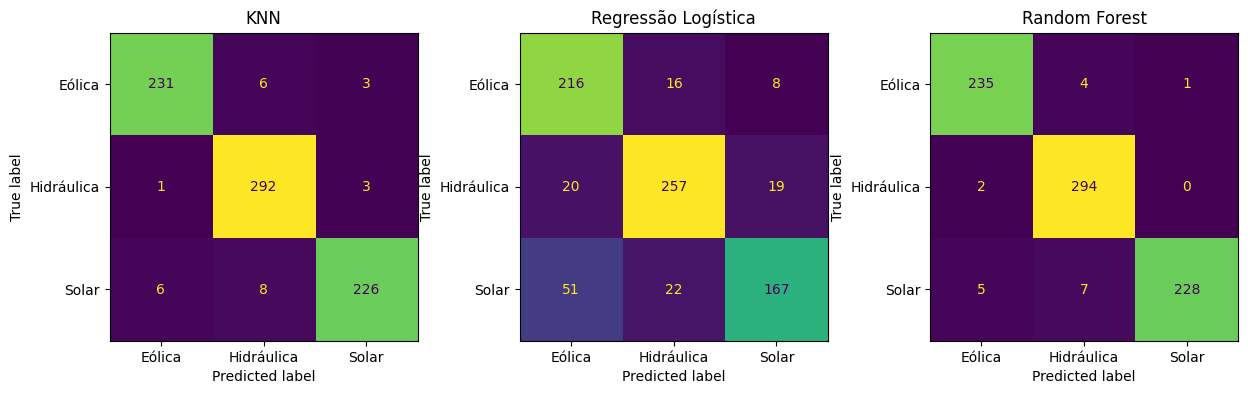

In [34]:
fig, eixos = plt.subplots(1, 3, figsize=(15, 4))
for eixo, (nome, modelo) in zip(eixos, modelos.items()):
    ConfusionMatrixDisplay.from_estimator(modelo, x_teste_esc, y_teste, ax=eixo, colorbar=False)
    eixo.set_title(nome)
plt.show()

In [35]:
from sklearn.metrics import classification_report

print(classification_report(y_teste, modelo_rf.predict(x_teste_esc)))

              precision    recall  f1-score   support

      Eólica       0.97      0.98      0.98       240
  Hidráulica       0.96      0.99      0.98       296
       Solar       1.00      0.95      0.97       240

    accuracy                           0.98       776
   macro avg       0.98      0.97      0.98       776
weighted avg       0.98      0.98      0.98       776



Escolheria o Random Forest, pois teve o maior F1 macro (0,975) e a maior accuracy (0,976) entre os três modelos.

Pela matriz de confusão, ele mais confunde Solar com Hidráulica (7 casos) e Solar com Eólica (5 casos). Os erros se concentram na classe Solar, que tem o menor recall (0,95), enquanto a Hidráulica tem o maior (0,99). Isso acontece porque usinas solares e eólicas têm faixas de potência que se sobrepõem e podem estar na mesma região, e a classe Hidráulica reúne UHE, PCH e CGH, de portes muito variados, o que cobre faixas de potência de várias outras usinas.

A Regressão Logística foi a pior (F1 macro 0,820), principalmente por confundir Solar com Eólica (51 casos). Como ela traça fronteiras lineares entre as classes e a relação entre potência, localização e fonte não é linear, ela não consegue separá-las bem. O KNN e o Random Forest, que se baseiam em vizinhança e em regras por regiões, se saem melhor.

Potência e localização podem não bastar numa aplicação real porque:
- as faixas de potência de solar, eólica e hidráulica se sobrepõem;
- a classe Hidráulica junta UHE, PCH e CGH, que têm portes muito diferentes;
- as coordenadas são aproximadas e não dizem nada sobre o recurso natural disponível (vento, sol, rio);
- as classes são um pouco desequilibradas (Hidráulica tem mais exemplos), então o modelo tende a favorecer a classe maior;
- o modelo aprendeu a classificar o cadastro da ANEEL, e não a identificar a fonte de um empreendimento novo ou desconhecido.

# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [36]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [37]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

Campos recebidos: ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}
Quantidade de horários: 2184


### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [38]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

Horas válidas: 1001
Primeiro exemplo: ['2025-04-01T07:00', 25.3, 74, 100, 17.7, 7, 116.0]


In [39]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

Salvo: meteo_regressao_orange.csv


### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

In [40]:
df_meteo = pd.read_csv('/content/meteo_regressao_orange.csv')
df_meteo.head()

,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
0,2025-04-01T07:00,25.3,74,100,17.7,7,116.0
1,2025-04-01T08:00,26.5,66,100,18.1,8,269.0
2,2025-04-01T09:00,28.4,55,97,18.0,9,529.0
3,2025-04-01T10:00,30.8,44,21,18.4,10,797.0
4,2025-04-01T11:00,32.7,36,26,20.1,11,880.0


In [41]:
print(df_meteo.shape)
print(df_meteo.isnull().sum())
df_meteo.describe()

(1001, 7)
data_hora        0
temperatura_c    0
umidade_pct      0
nuvens_pct       0
vento_kmh        0
hora             0
radiacao_w_m2    0
dtype: int64


,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,28.885914,50.544456,55.108891,15.465435,12.000000,472.854146
std,3.656514,15.913965,37.851461,4.923631,3.163858,256.368950
min,19.500000,21.000000,0.000000,2.300000,7.000000,13.000000
25%,26.300000,38.000000,19.000000,12.200000,9.000000,250.000000
50%,29.100000,49.000000,54.000000,15.400000,12.000000,466.000000
75%,31.700000,61.000000,98.000000,19.000000,15.000000,696.000000
max,36.100000,95.000000,100.000000,30.100000,17.000000,1002.000000


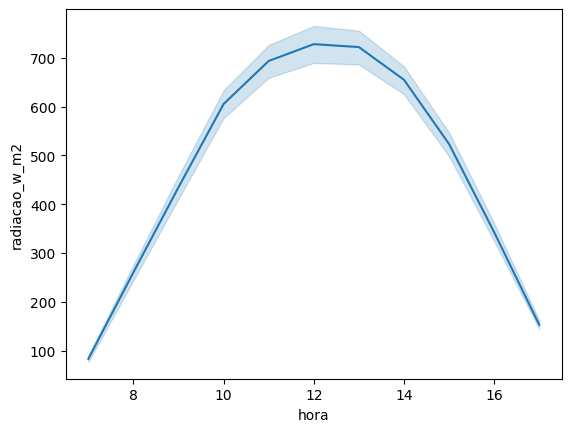

In [42]:
sns.lineplot(data=df_meteo, x='hora', y='radiacao_w_m2')
plt.show()

In [43]:
x = df_meteo[['temperatura_c', 'umidade_pct', 'nuvens_pct', 'vento_kmh', 'hora']]
y = df_meteo['radiacao_w_m2']

In [44]:
from sklearn.preprocessing import StandardScaler

corte = int(len(df_meteo) * 0.8)
x_treino, x_teste = x.iloc[:corte], x.iloc[corte:]
y_treino, y_teste = y.iloc[:corte], y.iloc[corte:]

escala = StandardScaler()
x_treino_esc = escala.fit_transform(x_treino)
x_teste_esc = escala.transform(x_teste)

In [45]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

modelo_lr = LinearRegression()
modelo_knn = KNeighborsRegressor()
modelo_rf = RandomForestRegressor(random_state=42)

modelo_lr.fit(x_treino_esc, y_treino)
modelo_knn.fit(x_treino_esc, y_treino)
modelo_rf.fit(x_treino_esc, y_treino)

RandomForestRegressor(random_state=42)

In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

modelos = {'Regressão Linear': modelo_lr, 'KNN': modelo_knn, 'Random Forest': modelo_rf}

linhas = []
for nome, modelo in modelos.items():
    y_pred = modelo.predict(x_teste_esc)
    linhas.append({
        'Modelo': nome,
        'MAE (W/m²)': mean_absolute_error(y_teste, y_pred),
        'MSE ((W/m²)²)': mean_squared_error(y_teste, y_pred),
        'R²': r2_score(y_teste, y_pred)
    })

pd.DataFrame(linhas).round(3)

,Modelo,MAE (W/m²),MSE ((W/m²)²),R²
0,Regressão Linear,145.205,30034.201,0.360
1,KNN,68.271,7607.961,0.838
2,Random Forest,66.709,7278.122,0.845


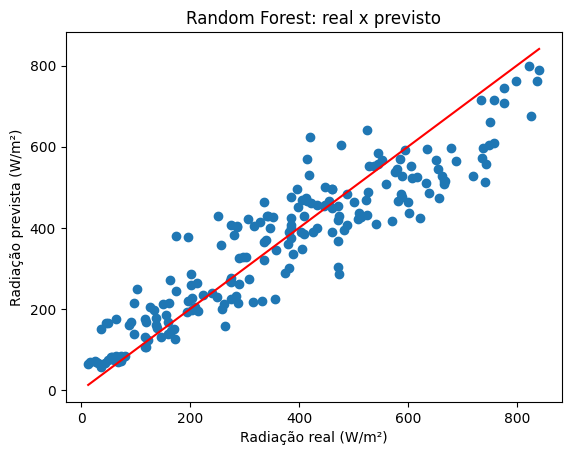

In [47]:
y_pred_rf = modelo_rf.predict(x_teste_esc)

plt.scatter(y_teste, y_pred_rf)
plt.plot([y_teste.min(), y_teste.max()], [y_teste.min(), y_teste.max()], color='red')
plt.xlabel('Radiação real (W/m²)')
plt.ylabel('Radiação prevista (W/m²)')
plt.title('Random Forest: real x previsto')
plt.show()

In [48]:
x_sem_hora_treino = escala.fit_transform(x_treino.drop(columns='hora'))
x_sem_hora_teste = escala.transform(x_teste.drop(columns='hora'))

rf_sem_hora = RandomForestRegressor(random_state=42).fit(x_sem_hora_treino, y_treino)
print(r2_score(y_teste, rf_sem_hora.predict(x_sem_hora_teste)))

0.3282142891173139


O Random Forest foi o melhor (MAE 66,7 W/m², MSE 7278,1 e R² 0,845), seguido de perto pelo KNN (R² 0,838). A Regressão Linear foi a pior (MAE 145,2 W/m², R² 0,360), porque a radiação não varia em linha reta com as entradas: ela sobe até o meio do dia e depois desce, e um modelo linear não consegue representar esse formato de sino.

O erro médio de cerca de 67 W/m² do Random Forest é moderado perto da média da radiação no teste (cerca de 373 W/m²). Os pontos do gráfico real x previsto ficam próximos da linha vermelha, mas se espalham mais nos valores mais altos.

A hora tem um peso grande: ela foi a variável mais importante do Random Forest (cerca de 49%). Ao retirar a hora, o R² do Random Forest caiu de 0,845 para 0,328, ou seja, a posição do sol no dia explica a maior parte da variação da radiação.

Além disso, o período de teste (de 12 de junho a 30 de junho) tem radiação média menor do que a do treino, porque é inverno e o sol é mais baixo. Isso dificulta a previsão, já que o modelo aprendeu com meses mais ensolarados.

Essa estimativa de radiação não prevê automaticamente a energia produzida por um sistema fotovoltaico, porque:
- a radiação é medida em W/m² (potência por área), enquanto a energia gerada é em kWh e depende também da área e da eficiência dos painéis;
- a temperatura dos painéis, a sujeira, a inclinação, a sombra e as perdas no inversor reduzem a geração;
- os dados são estimados por modelos/reanálise, e não leituras de um sensor no local.

# Entrega pelo GitHub

Envie **apenas o link do repositório público**. Organize-o com:

- `README.md` contendo objetivo, fontes e período dos dados, instruções para executar o notebook e resumo dos resultados;
- notebook `.ipynb` com a consulta às APIs, sua análise, os **três classificadores e os três regressores**, todos os imports necessários adicionados por você e conclusões em Markdown;
- os dois CSVs gerados (ou instruções completas e testadas para reproduzi-los) e eventuais figuras utilizadas.

Verifique se o notebook roda **na ordem das células** a partir de um ambiente limpo. Não inclua senhas, tokens ou arquivos sem relação com a avaliação. A banca deve conseguir encontrar as seis comparações e as respostas às duas tarefas sem procurar uma agulha no palheiro.

### Fontes

- [ANEEL — SIGA](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel)
- [ANEEL — recurso e campos usados](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel/resource/11ec447d-698d-4ab8-977f-b424d5deee6a)
- [Open-Meteo — histórico e unidades](https://open-meteo.com/en/docs/historical-weather-api)